In [ ]:
import torch, platform

print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.12
Torch: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [ ]:
!pip -q install -U transformers datasets evaluate scikit-learn accelerate

In [ ]:
from datasets import load_dataset

candidates = [
    "SetFit/sms_spam",
    "sms_spam",
]

ds = None
for name in candidates:
    try:
        ds = load_dataset(name)
        print("Loaded:", name)
        print(ds)
        break
    except Exception as e:
        print("Failed:", name, "|", e)

assert ds is not None, "No dataset could be loaded"


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Failed: SetFit/sms_spam | Dataset 'SetFit/sms_spam' doesn't exist on the Hub or cannot be accessed.
Loaded: sms_spam
DatasetDict({
    train: Dataset({
        features: ['sms', 'label'],
        num_rows: 5574
    })
})


In [ ]:
# Confirm if Dataset is loaded correctly
print(ds)

DatasetDict({
    train: Dataset({
        features: ['sms', 'label'],
        num_rows: 5574
    })
})


In [ ]:
# Setting
SEED = 42
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 64

In [ ]:
SEED = 42

# 1) 80/20 split (train / temp)
split1 = ds["train"].train_test_split(
    test_size=0.2,
    seed=SEED,
    stratify_by_column="label",
)
train_ds = split1["train"]
temp_ds  = split1["test"]

# 2) 10/10 split (val / test) from temp
split2 = temp_ds.train_test_split(
    test_size=0.5,
    seed=SEED,
    stratify_by_column="label",
)
val_ds  = split2["train"]
test_ds = split2["test"]

print("sizes:", len(train_ds), len(val_ds), len(test_ds))


sizes: 4459 557 558


In [ ]:
def label_ratio(d):
    c = d["label"]
    return {0: c.count(0), 1: c.count(1), "total": len(c)}

print("train:", label_ratio(train_ds))
print("val  :", label_ratio(val_ds))
print("test :", label_ratio(test_ds))

train: {0: 3861, 1: 598, 'total': 4459}
val  : {0: 483, 1: 74, 'total': 557}
test : {0: 483, 1: 75, 'total': 558}


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Show a sample text
sample_text = train_ds[0]["sms"]

enc = tokenizer(sample_text)
print("text:", sample_text)
print("keys:", enc.keys())
print("input_ids[:20]:", enc["input_ids"][:20])
print("tokens[:20]:", tokenizer.convert_ids_to_tokens(enc["input_ids"][:20]))


text: Dont you have message offer

keys: KeysView({'input_ids': [101, 2123, 2102, 2017, 2031, 4471, 3749, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]})
input_ids[:20]: [101, 2123, 2102, 2017, 2031, 4471, 3749, 102]
tokens[:20]: ['[CLS]', 'don', '##t', 'you', 'have', 'message', 'offer', '[SEP]']


In [ ]:
# Padding & truncation
texts = [
    train_ds[0]["sms"],
    train_ds[1]["sms"],
]

enc = tokenizer(
    texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt",
)

print("input_ids shape:", enc["input_ids"].shape)
print("attention_mask shape:", enc["attention_mask"].shape)

print("\ninput_ids[0][:20]:", enc["input_ids"][0][:20])
print("attention_mask[0][:20]:", enc["attention_mask"][0][:20])

print("\ninput_ids[1][:20]:", enc["input_ids"][1][:20])
print("attention_mask[1][:20]:", enc["attention_mask"][1][:20])


input_ids shape: torch.Size([2, 128])
attention_mask shape: torch.Size([2, 128])

input_ids[0][:20]: tensor([ 101, 2123, 2102, 2017, 2031, 4471, 3749,  102,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])
attention_mask[0][:20]: tensor([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

input_ids[1][:20]: tensor([  101,  1057,  2035,  4339,  2030, 28194,  1012,  1012,   102,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])
attention_mask[1][:20]: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [ ]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    """
    Args:
        batch (list of dict):
            Each element contains:
              - 'sms'   : raw text
              - 'label' : integer label (0 or 1)

    Returns:
        dict with:
          - input_ids      : Tensor (B, T)
          - attention_mask : Tensor (B, T)
          - labels         : Tensor (B,)
    """

    # Extract texts and labels from the batch
    texts = [x["sms"] for x in batch]
    labels = torch.tensor(
        [x["label"] for x in batch],
        dtype=torch.long  # Required for CrossEntropyLoss
    )

    # Tokenize texts into padded tensors
    enc = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )

    return {
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels": labels,
    }


# Create a DataLoader and inspect one batch
train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn,
)

batch = next(iter(train_loader))
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)
print("labels dtype:", batch["labels"].dtype)

torch.Size([8, 128])
torch.Size([8, 128])
torch.Size([8])
labels dtype: torch.int64


In [ ]:
import torch.nn as nn

class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        emb_dim: int = 128,
        hidden_dim: int = 128,
        num_classes: int = 2,
        pad_token_id: int = 0,
    ):
        super().__init__()

        # Embedding layer: token ids -> dense vectors
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_token_id,  # PAD tokens produce zero vectors
        )

        # Bidirectional LSTM encoder
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )

        # Linear classifier on top of pooled sequence representation
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        """
        Args:
            input_ids (Tensor): shape (B, T)
            attention_mask (Tensor): shape (B, T)

        Returns:
            logits (Tensor): shape (B, num_classes)
        """

        # (B, T) -> (B, T, E)
        x = self.embedding(input_ids)

        # (B, T, E) -> (B, T, 2H)
        outputs, _ = self.lstm(x)

        # Masked mean pooling
        # Expand attention mask to (B, T, 1)
        mask = attention_mask.unsqueeze(-1)

        # Zero-out padded positions
        outputs = outputs * mask

        # Sum over time dimension
        summed = outputs.sum(dim=1)

        # Count valid (non-padding) tokens
        lengths = mask.sum(dim=1).clamp(min=1e-6)

        # Compute mean pooled representation
        pooled = summed / lengths

        # (B, 2H) -> (B, num_classes)
        logits = self.classifier(pooled)

        return logits

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch.optim as optim


# ---- DataLoaders (explicitly defined here for clarity) ----
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)


# ---- Device setup ----
device = "cuda" if torch.cuda.is_available() else "cpu"


# ---- Model, loss, optimizer ----
model = BiLSTMClassifier(
    vocab_size=tokenizer.vocab_size,
    pad_token_id=tokenizer.pad_token_id,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-3)


def run_epoch(model, loader, train: bool):
    """
    Run one epoch for training or evaluation.
    """
    model.train() if train else model.eval()

    all_labels = []
    all_preds = []
    total_loss = 0.0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        if train:
            optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=-1)
        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
    }


# ---- Run training (1 epoch) ----
train_metrics = run_epoch(model, train_loader, train=True)
val_metrics = run_epoch(model, val_loader, train=False)

print("Train metrics:", train_metrics)
print("Val metrics  :", val_metrics)


Train metrics: {'loss': 0.16273340448471052, 'accuracy': 0.9289078268670106, 'precision': 0.8385542168674699, 'recall': 0.5819397993311036, 'f1': 0.6870681145113524}
Val metrics  : {'loss': 0.05660923673874802, 'accuracy': 0.9856373429084381, 'precision': 1.0, 'recall': 0.8918918918918919, 'f1': 0.9428571428571428}


In [ ]:
import copy  # New import: used to deep-copy model weights


# ---- DataLoaders (explicitly defined here for reproducibility) ----
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)


# ---- Device setup ----
device = "cuda" if torch.cuda.is_available() else "cpu"


# ---- Model, loss, optimizer ----
model = BiLSTMClassifier(
    vocab_size=tokenizer.vocab_size,
    pad_token_id=tokenizer.pad_token_id,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-3)


def run_epoch(model, loader, train: bool):
    """
    Run one epoch for training or evaluation.
    Returns a metrics dict.
    """
    model.train() if train else model.eval()

    all_labels = []
    all_preds = []
    total_loss = 0.0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        if train:
            optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=-1)
        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
    }


# ---- Training loop ----
EPOCHS = 8

history = {
    "train": [],
    "val": [],
}

best_val_f1 = -1.0
best_state = None
best_epoch = None

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, train=True)
    val_metrics = run_epoch(model, val_loader, train=False)

    history["train"].append(train_metrics)
    history["val"].append(val_metrics)

    print(
        f"[Epoch {epoch}/{EPOCHS}] "
        f"train_loss={train_metrics['loss']:.4f} train_f1={train_metrics['f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['f1']:.4f} "
        f"(val_P={val_metrics['precision']:.4f}, val_R={val_metrics['recall']:.4f}, val_acc={val_metrics['accuracy']:.4f})"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch


print("\nBest checkpoint:")
print("best_epoch:", best_epoch)
print("best_val_f1:", best_val_f1)


# ---- Load best checkpoint back into the model (for later testing) ----
model.load_state_dict(best_state)

[Epoch 1/8] train_loss=0.1606 train_f1=0.7325 | val_loss=0.0409 val_f1=0.9504 (val_P=1.0000, val_R=0.9054, val_acc=0.9874)
[Epoch 2/8] train_loss=0.0298 train_f1=0.9669 | val_loss=0.0341 val_f1=0.9722 (val_P=1.0000, val_R=0.9459, val_acc=0.9928)
[Epoch 3/8] train_loss=0.0100 train_f1=0.9907 | val_loss=0.0304 val_f1=0.9726 (val_P=0.9861, val_R=0.9595, val_acc=0.9928)
[Epoch 4/8] train_loss=0.0058 train_f1=0.9950 | val_loss=0.0286 val_f1=0.9793 (val_P=1.0000, val_R=0.9595, val_acc=0.9946)
[Epoch 5/8] train_loss=0.0026 train_f1=0.9958 | val_loss=0.0486 val_f1=0.9577 (val_P=1.0000, val_R=0.9189, val_acc=0.9892)
[Epoch 6/8] train_loss=0.0059 train_f1=0.9950 | val_loss=0.0371 val_f1=0.9589 (val_P=0.9722, val_R=0.9459, val_acc=0.9892)
[Epoch 7/8] train_loss=0.0076 train_f1=0.9908 | val_loss=0.0427 val_f1=0.9517 (val_P=0.9718, val_R=0.9324, val_acc=0.9874)
[Epoch 8/8] train_loss=0.0013 train_f1=0.9992 | val_loss=0.0402 val_f1=0.9730 (val_P=0.9730, val_R=0.9730, val_acc=0.9928)

Best checkpoint

<All keys matched successfully>

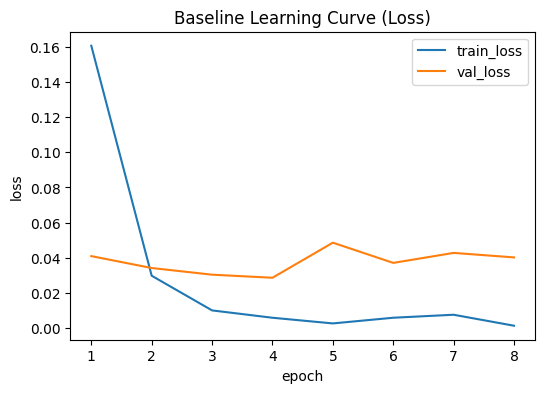

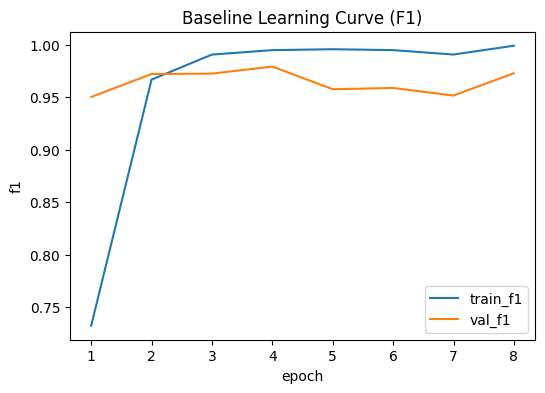

In [ ]:
# What: Visualize learning curves (loss and F1) from the training history.
# Why: Required for report; display only (no file saving needed in Colab).

import matplotlib.pyplot as plt

epochs = list(range(1, EPOCHS + 1))

train_loss = [m["loss"] for m in history["train"]]
val_loss   = [m["loss"] for m in history["val"]]
train_f1   = [m["f1"] for m in history["train"]]
val_f1     = [m["f1"] for m in history["val"]]

plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss, label="train_loss")
plt.plot(epochs, val_loss, label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Baseline Learning Curve (Loss)")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, train_f1, label="train_f1")
plt.plot(epochs, val_f1, label="val_f1")
plt.xlabel("epoch")
plt.ylabel("f1")
plt.title("Baseline Learning Curve (F1)")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix


# ---- Test DataLoader ----
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)


def run_test(model, loader):
    """
    Evaluate the model on the test set.
    Returns metrics, confusion matrix, and raw predictions for error analysis.
    """
    model.eval()

    all_labels = []
    all_preds = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=-1)
            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", zero_division=0
    )
    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "confusion_matrix": cm,
        "y_true": all_labels,
        "y_pred": all_preds,
    }


# ---- Run test evaluation ----
test_metrics = run_test(model, test_loader)

print("Test metrics:")
for k, v in test_metrics.items():
    if k != "confusion_matrix":
        print(f"{k}: {v}")

print("\nConfusion Matrix:")
print(test_metrics["confusion_matrix"])

Test metrics:
loss: 0.04942538832417793
accuracy: 0.982078853046595
precision: 0.9577464788732394
recall: 0.9066666666666666
f1: 0.9315068493150684
y_true: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 

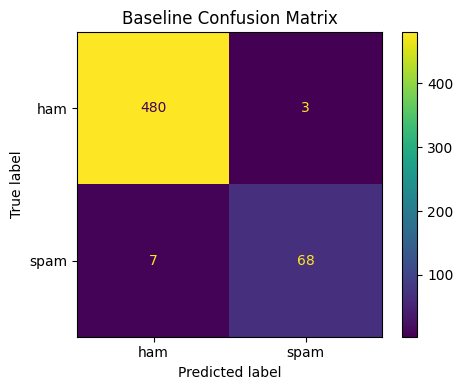

In [ ]:
# What: Display confusion matrix as a figure.
# Why: Required for report; display only in Colab.

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

cm = np.array(test_metrics["confusion_matrix"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])

fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, values_format="d")
ax.set_title("Baseline Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
# What: Extract false positives/negatives from baseline predictions.
# Why: Required for report error analysis.

import pandas as pd

texts_test = test_ds["sms"]                 # Raw texts aligned with test_ds order (shuffle=False)
y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]

assert len(texts_test) == len(y_true) == len(y_pred), "Length mismatch in test outputs."

df_err = pd.DataFrame({
    "text": texts_test,
    "y_true": y_true,
    "y_pred": y_pred,
})

fp = df_err[(df_err.y_true == 0) & (df_err.y_pred == 1)]
fn = df_err[(df_err.y_true == 1) & (df_err.y_pred == 0)]

print("=== False Positives (Ham -> Spam) ===")
for _, row in fp.head(3).iterrows():
    print(f"\nText: {row['text']}")

print("\n=== False Negatives (Spam -> Ham) ===")
for _, row in fn.head(3).iterrows():
    print(f"\nText: {row['text']}")


=== False Positives (Ham -> Spam) ===

Text: Ill call u 2mrw at ninish, with my address that icky American freek wont stop callin me 2 bad Jen k eh?


Text: Hi hope u get this txt~journey hasnt been gd,now about 50 mins late I think.


Text: MY NO. IN LUTON 0125698789 RING ME IF UR AROUND! H*


=== False Negatives (Spam -> Ham) ===

Text: Do you ever notice that when you're driving, anyone going slower than you is an idiot and everyone driving faster than you is a maniac?


Text: You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 750


Text: How come it takes so little time for a child who is afraid of the dark to become a teenager who wants to stay out all night?

